In [1]:
import os
import mne
import numpy as np
import xml.etree.ElementTree as ET
from scipy.interpolate import interp1d
from mne.preprocessing.ecg import find_ecg_events
from scipy.signal import welch, medfilt
from scipy.integrate import trapezoid

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Load Original Data
X_sig = np.load('X2_data.npy').astype('float32') 
X_feat = np.load('X2_features.npy').astype('float32')
y = np.load('Y2_labels.npy').astype('int')

# 2. Combine Signals + Features
X_combined = np.hstack([X_sig.reshape(len(X_sig), -1), X_feat])

# 3. Train / Validation / Test Split
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    X_combined, y, test_size=0.30, random_state=42, stratify=y
)

# 15% Validation - 15% Test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 4. Apply SMOTE on Training Set Only
sm = SMOTE(random_state=42)
X_train_res, y_train = sm.fit_resample(X_train_raw, y_train_raw)

# 5. Separate Signals and Features Again
def process_back(data):
    sigs = data[:, :120].reshape(-1, 1, 120) # 1 channel
    feats = data[:, 120:]
    return sigs, feats

X_train_sig, X_train_feat = process_back(X_train_res)
X_val_sig, X_val_feat = process_back(X_val_raw)
X_test_sig, X_test_feat = process_back(X_test_raw)

# 6. Smooth Only New Synthetic Training Samples
indices_new = np.arange(len(X_train_raw), len(X_train_res))
for i in indices_new:
    X_train_sig[i, 0, :] = np.convolve(X_train_sig[i, 0, :], np.ones(5)/5, mode='same')

# 7. Combine Signals + Features for Temporal Model
X_train_final = np.concatenate([X_train_sig, X_train_feat[:, np.newaxis, :]], axis=2)
X_val_final = np.concatenate([X_val_sig, X_val_feat[:, np.newaxis, :]], axis=2)
X_test_final = np.concatenate([X_test_sig, X_test_feat[:, np.newaxis, :]], axis=2)

print(f" Done! Train: {len(X_train_final)}, Val: {len(X_val_final)}, Test: {len(X_test_final)}")

 Done! Train: 17895, Val: 1845, Test: 1846


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Dataset تسحب 5 نوافذ متتالية
class SleepSequenceDataset(Dataset):
    def __init__(self, X, y, seq_len=5):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len
    def __len__(self):
        return len(self.X) - self.seq_len + 1
    def __getitem__(self, idx):
        return self.X[idx : idx + self.seq_len], self.y[idx + self.seq_len - 1]

train_loader = DataLoader(SleepSequenceDataset(X_train_final, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(SleepSequenceDataset(X_val_final, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(SleepSequenceDataset(X_test_final, y_test), batch_size=64, shuffle=False)

# الموديل (TemporalSleepModel)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride), nn.BatchNorm1d(out_channels))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x))); out = self.bn2(self.conv2(out))
        out += self.shortcut(x); return F.relu(out)

class TemporalSleepModel(nn.Module):
    def __init__(self, num_classes=5):
        super(TemporalSleepModel, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=7, stride=1, padding=3)
        self.bn1 = nn.BatchNorm1d(16)
        self.layer1 = ResidualBlock(16, 16); self.layer2 = ResidualBlock(16, 32, stride=2); self.layer3 = ResidualBlock(32, 64, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x):
        b, s, c, l = x.size()
        x = x.view(b * s, c, l)
        x = F.relu(self.bn1(self.conv1(x))); x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        x = self.avg_pool(x).view(b, s, -1)
        x, _ = self.lstm(x)
        return self.fc(x[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TemporalSleepModel().to(device)

🚀 Starting Temporal Training on: cpu...
Epoch [1/35] | Train Acc: 44.83% | Val Acc: 49.54% | LR: 0.000500  Best Model Saved!
Epoch [2/35] | Train Acc: 61.86% | Val Acc: 52.91% | LR: 0.000500  Best Model Saved!
Epoch [3/35] | Train Acc: 64.97% | Val Acc: 50.30% | LR: 0.000500 
Epoch [4/35] | Train Acc: 67.33% | Val Acc: 50.57% | LR: 0.000500 
Epoch [5/35] | Train Acc: 69.63% | Val Acc: 54.75% | LR: 0.000500  Best Model Saved!
Epoch [6/35] | Train Acc: 70.92% | Val Acc: 54.43% | LR: 0.000500 
Epoch [7/35] | Train Acc: 72.28% | Val Acc: 54.48% | LR: 0.000500 
Epoch [8/35] | Train Acc: 73.33% | Val Acc: 54.43% | LR: 0.000500 
Epoch [9/35] | Train Acc: 73.89% | Val Acc: 54.54% | LR: 0.000500 
Epoch [10/35] | Train Acc: 74.91% | Val Acc: 55.73% | LR: 0.000500  Best Model Saved!
Epoch [11/35] | Train Acc: 75.47% | Val Acc: 54.21% | LR: 0.000500 
Epoch [12/35] | Train Acc: 75.98% | Val Acc: 56.22% | LR: 0.000500  Best Model Saved!
Epoch [13/35] | Train Acc: 76.54% | Val Acc: 57.03% | LR: 0.000

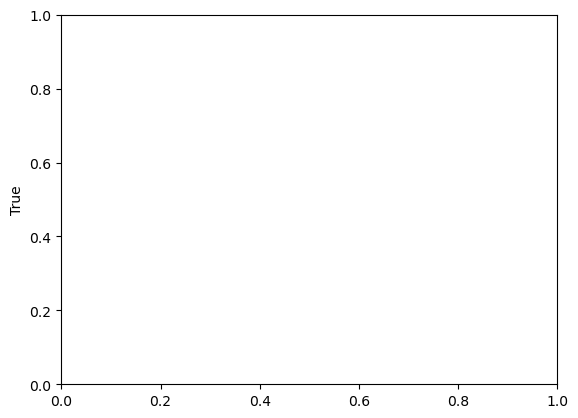

In [4]:
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5
)

criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
epochs = 35

print(f"🚀 Starting Temporal Training on: {device}...")

for epoch in range(epochs):

    model.train()

    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        # Backpropagation
        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total_train += batch_y.size(0)

        correct_train += (
            predicted == batch_y
        ).sum().item()

    train_acc = correct_train / total_train

    # VALIDATION 
    model.eval()

    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            _, predicted = torch.max(outputs.data, 1)

            total_val += batch_y.size(0)

            correct_val += (
                predicted == batch_y
            ).sum().item()

    val_acc = correct_val / total_val
    
    # Update learning rate
    scheduler.step(val_acc)

    # Save Best Model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            'best_temporal_model.pth'
        )

        msg = " Best Model Saved!"

    else:
        msg = ""

    #  Results
  

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Acc: {100 * train_acc:.2f}% | "
        f"Val Acc: {100 * val_acc:.2f}% | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f} "
        f"{msg}"
    )

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc * 100:.2f}%"
)
plt.ylabel('True')
plt.show()

 Starting Evaluation on Test Set...

 Classification Report:
              precision    recall  f1-score   support

        Wake       0.63      0.78      0.69       765
          S1       0.00      0.00      0.00       141
          S2       0.49      0.70      0.58       618
          S3       0.00      0.00      0.00       129
          S4       0.33      0.03      0.06       189

    accuracy                           0.56      1842
   macro avg       0.29      0.30      0.27      1842
weighted avg       0.46      0.56      0.49      1842



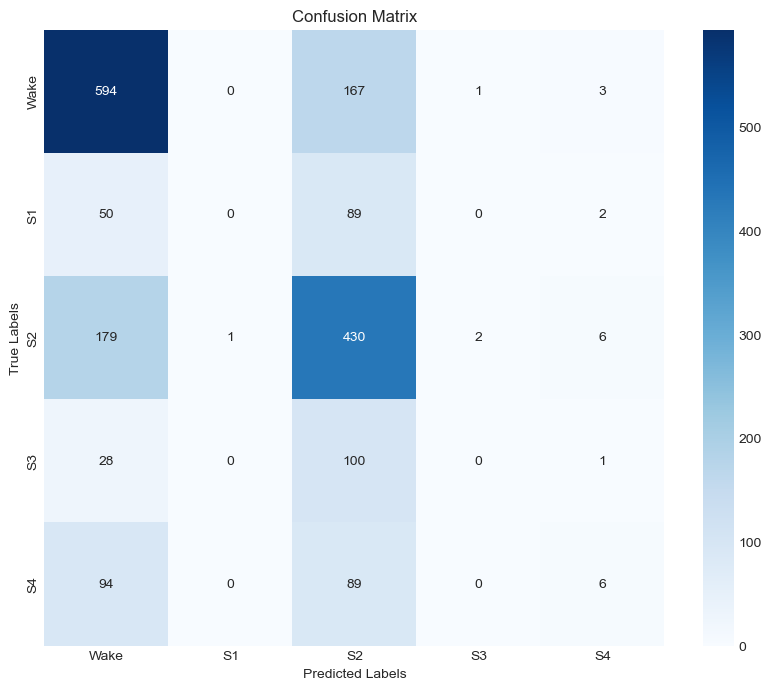

 Final Test Accuracy: 55.92%


In [16]:
# 1. تحميل أفضل الأوزان
from sklearn.metrics import accuracy_score


model.load_state_dict(torch.load('best_temporal_model.pth'))
model.eval()

all_preds = []
all_labels = []

print(" Starting Evaluation on Test Set...")

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)
        _, predicted = torch.max(outputs, 1)

        # الحل هنا: نستخدم .tolist() بدل .numpy() لتجنب RuntimeError
        all_preds.extend(predicted.cpu().detach().tolist())
        all_labels.extend(batch_y.cpu().detach().tolist())

# باقي الكود كما هو (الرسم والتقرير)
print("\n Classification Report:")
target_names = ['Wake', 'S1', 'S2', 'S3', 'S4']
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
test_acc = accuracy_score(all_labels, all_preds)

print(f" Final Test Accuracy: {test_acc * 100:.2f}%")

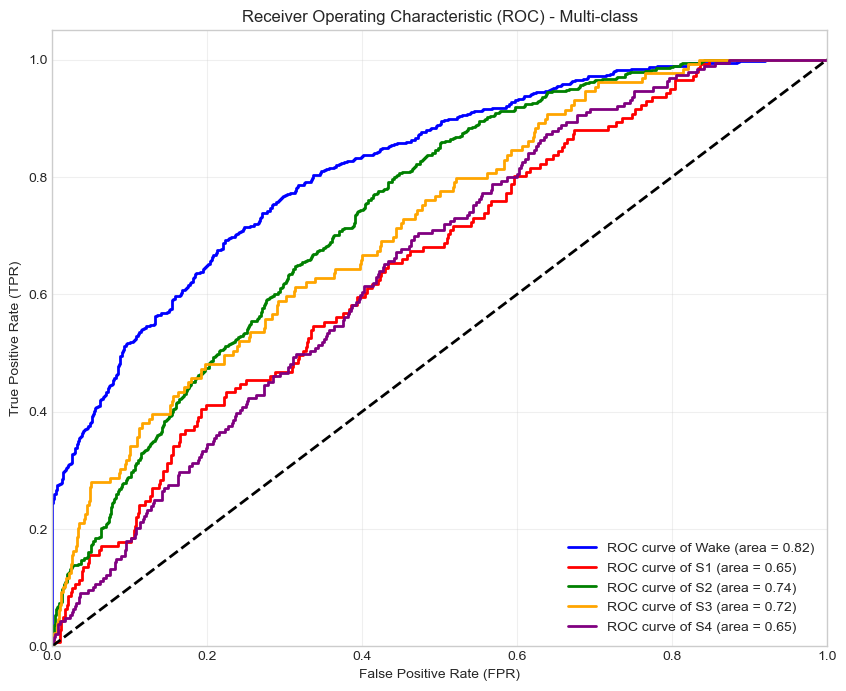

In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. تحويل الموديل لوضع التقييم وحساب الاحتمالات
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        # تحويل المخرجات إلى احتمالات باستخدام Softmax
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())

# 2. تجهيز البيانات (Binarize labels)
# افترضنا هنا أن عدد الكلاسات 5 (من 0 لـ 4)
n_classes = 5
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])
all_probs = np.array(all_probs)

# 3. حساب ROC و AUC لكل فئة
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. رسم المنحنيات
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
target_names = ['Wake', 'S1', 'S2', 'S3', 'S4']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {target_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # خط العشوائية
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import torch.optim as optim

# الإعدادات المتقدمة للتدريب
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
epochs = 40

print(f"🚀 Starting Temporal Training on: {device}...")

for epoch in range(epochs):
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x) # الآن الـ forward سيستقبل 4 أبعاد ولن يحدث خطأ
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    # مرحلة التقييم (Validation)
    model.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    val_acc = correct_val / total_val
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_temporal_model.pth')
        msg = "🌟 Saved!"
    else:
        msg = ""

    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {100*correct_train/total_train:.2f}% | Val Acc: {100*val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f} {msg}")

print(f"\n Done! Best Val Accuracy: {best_val_acc*100:.2f}%")

🚀 Starting Temporal Training on: cpu...
Epoch [1/40] | Train Acc: 44.17% | Val Acc: 50.68% | LR: 0.000500 🌟 Saved!
Epoch [2/40] | Train Acc: 57.65% | Val Acc: 49.00% | LR: 0.000500 
Epoch [3/40] | Train Acc: 63.21% | Val Acc: 54.26% | LR: 0.000500 🌟 Saved!
Epoch [4/40] | Train Acc: 66.63% | Val Acc: 53.72% | LR: 0.000500 
Epoch [5/40] | Train Acc: 68.93% | Val Acc: 54.64% | LR: 0.000500 🌟 Saved!
Epoch [6/40] | Train Acc: 71.04% | Val Acc: 53.39% | LR: 0.000500 
Epoch [7/40] | Train Acc: 72.49% | Val Acc: 53.94% | LR: 0.000500 
Epoch [8/40] | Train Acc: 73.66% | Val Acc: 57.41% | LR: 0.000500 🌟 Saved!
Epoch [9/40] | Train Acc: 74.84% | Val Acc: 58.88% | LR: 0.000500 🌟 Saved!
Epoch [10/40] | Train Acc: 75.70% | Val Acc: 58.94% | LR: 0.000500 🌟 Saved!
Epoch [11/40] | Train Acc: 76.76% | Val Acc: 59.80% | LR: 0.000500 🌟 Saved!
Epoch [12/40] | Train Acc: 77.59% | Val Acc: 57.63% | LR: 0.000500 
Epoch [13/40] | Train Acc: 77.98% | Val Acc: 60.29% | LR: 0.000500 🌟 Saved!
Epoch [14/40] | Train

🚀 Testing on cpu... Please wait.

     FINAL TEST REPORT
              precision    recall  f1-score   support

        Wake       0.83      0.81      0.82       766
          S1       0.27      0.15      0.19       139
          S2       0.55      0.77      0.64       616
          S3       0.38      0.21      0.27       131
         REM       0.39      0.16      0.23       189

    accuracy                           0.64      1841
   macro avg       0.48      0.42      0.43      1841
weighted avg       0.61      0.64      0.61      1841



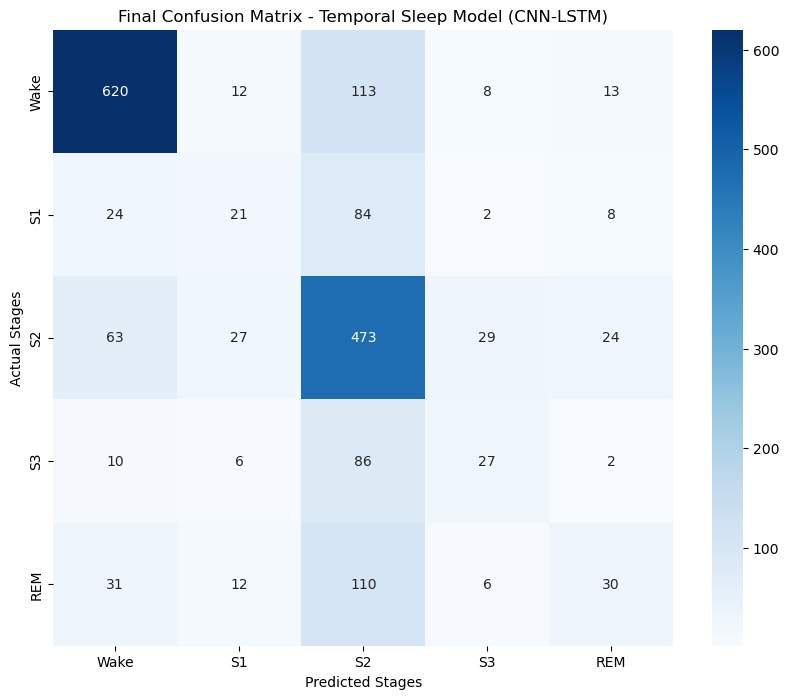


✨ Final Test Accuracy: 63.61%


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. تحميل الموديل والتأكد من تفعيل وضع التقييم (Evaluation Mode)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# تأكدي أن TemporalSleepModel معرف في الكود عندك
model_test = TemporalSleepModel(num_classes=5).to(device)
model_test.load_state_dict(torch.load('best_temporal_model.pth')) 
model_test.eval()

all_preds = []
all_labels = []

print(f"🚀 Testing on {device}... Please wait.")

# 2. البدء في التنبؤ بدون حساب Gradient لتوفير الذاكرة
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        outputs = model_test(batch_x)
        _, preds = torch.max(outputs, 1)
        
        # تحويل لـ list لتجنب أي تعارض مع نسخة numpy في conda
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())

# 3. تحويل النتائج النهائية لـ Arrays من أجل الحسابات الإحصائية
all_preds_np = np.array(all_preds)
all_labels_np = np.array(all_labels)

# 4. طباعة التقرير النهائي (Classification Report)
classes = ['Wake', 'S1', 'S2', 'S3', 'REM']
print("\n" + "="*30)
print("     FINAL TEST REPORT")
print("="*30)
print(classification_report(all_labels_np, all_preds_np, target_names=classes))

# 5. رسم الـ Confusion Matrix النهائية بشكل احترافي للمناقشة
cm = confusion_matrix(all_labels_np, all_preds_np)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix - Temporal Sleep Model (CNN-LSTM)')
plt.ylabel('Actual Stages')
plt.xlabel('Predicted Stages')
plt.show()

# 6. حساب الدقة الإجمالية النهائية
final_acc = (all_preds_np == all_labels_np).mean()
print(f"\n🚀  Final Test Accuracy: {final_acc*100:.2f}%")